In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

def remove_outliers(signal, z_thresh=3.0):
    """
    Replaces outliers (based on z-score) with NaN, 
    then linearly interpolates over them.
    
    Parameters
    ----------
    signal : 1D array
        Input signal to clean.
    z_thresh : float, optional
        Z-score threshold to mark outliers (default=3.0).
        
    Returns
    -------
    signal_no_outliers : 1D array
        Signal with outliers replaced by interpolated values.
    """
    signal = np.array(signal)
    mean_val = np.mean(signal)
    std_val = np.std(signal)

    # Calculate z-scores
    z_scores = (signal - mean_val) / (std_val + 1e-9)  # add small epsilon to avoid div-by-zero
    outlier_mask = np.abs(z_scores) > z_thresh
    
    # Copy and replace outliers with NaN
    signal_no_outliers = signal.copy()
    signal_no_outliers[outlier_mask] = np.nan
    
    # Interpolate over NaNs
    nans = np.isnan(signal_no_outliers)
    if np.any(nans):
        not_nans = np.logical_not(nans)
        # Linear interpolation
        signal_no_outliers[nans] = np.interp(np.flatnonzero(nans),
                                             np.flatnonzero(not_nans),
                                             signal_no_outliers[not_nans])
    
    return signal_no_outliers

def butter_bandpass_filter(data, low_cut, high_cut, fs, order=4):
    nyquist = 0.5 * fs
    low_norm  = low_cut  / nyquist
    high_norm = high_cut / nyquist
    b, a = butter(order, [low_norm, high_norm], btype='band')
    filtered_data = filtfilt(b, a, data)
    return filtered_data

def butter_lowpass_filter(signal, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

def butter_highpass_filter(signal, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

In [21]:
# --------------------------
# Adjust these paths:
folder_name = "2025_2_3_FlowPhantom_345EEGRoom_5minBaselinep36p36_30SecFlow_BW20_Front"

# Example base path (adjust to your system)
base_path = r"R:/Evan/Backup/Simulations/EM Imaging/VNA Recordings/2025/2025_2_3"

# Construct the full folder path
folder_path = f"{base_path}/{folder_name}"

# Build file names by appending standard patterns
elapsed_times_path = f"{folder_path}/{folder_name}_elapsedtimes.csv"
data_path_mag      = f"{folder_path}/{folder_name}S11_mag.csv"
data_path_phase    = f"{folder_path}/{folder_name}S11_phase.csv"
# --------------------------

# 1) Read each CSV with header=0 (first row is column name)
df_time = pd.read_csv(elapsed_times_path, header=0)   # e.g., column name "Time"
df_mag  = pd.read_csv(data_path_mag, header=0)        # e.g., column name "S11_Magnitude"
df_phase= pd.read_csv(data_path_phase, header=0)      # e.g., column name "S11_Phase"

# 2) Extract columns to numpy arrays
#    Replace 'Time' / 'S11_Magnitude' / 'S11_Phase' with actual column names if different
time         = df_time.iloc[:,0].values
s11_mag_raw  = df_mag.iloc[:,0].values
s11_phase_raw= df_phase.iloc[:,0].values

print("Time array shape:", time.shape)
print("S11_Mag array shape:", s11_mag_raw.shape)
print("S11_Phase array shape:", s11_phase_raw.shape)

# 2) Sampling frequency
dt = np.median(np.diff(time))
fs = 1.0 / dt

print(f"Sampling frequency = {fs:.3f} Hz")

cutoff_freq = 0.008  # Hz
s11_mag_lpfiltered = butter_highpass_filter(s11_mag_raw, cutoff=cutoff_freq, fs=fs, order=4)
s11_phase_lpfiltered = butter_highpass_filter(s11_phase_raw, cutoff=cutoff_freq, fs=fs, order=4)

# 3) Remove Outliers
s11_mag_no_outliers = remove_outliers(s11_mag_lpfiltered, z_thresh=2)
s11_phase_no_outliers = remove_outliers(s11_phase_lpfiltered, z_thresh=2)

Time array shape: (600,)
S11_Mag array shape: (600,)
S11_Phase array shape: (600,)
Sampling frequency = 1.979 Hz


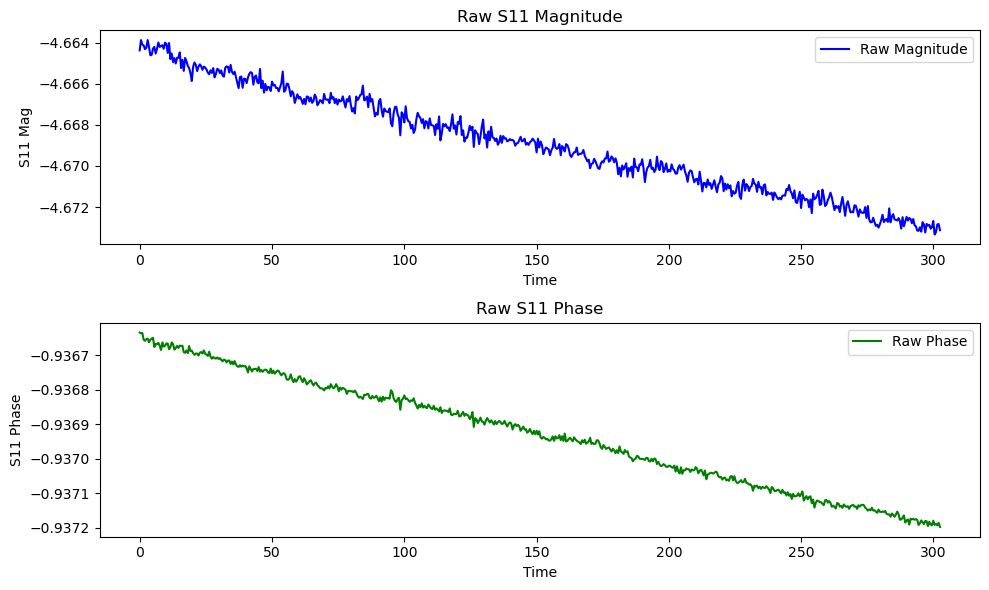

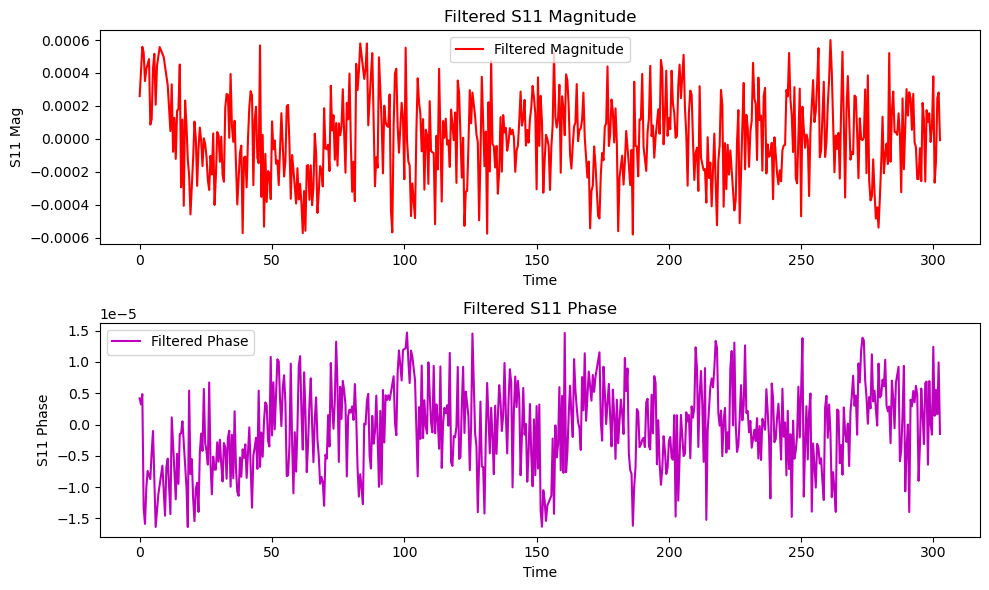

In [22]:
#---------------------------------------------------
# PLOTTING in separate figures
#---------------------------------------------------

# Figure 1: RAW data only
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(time, s11_mag_raw, 'b-', label='Raw Magnitude')
plt.xlabel('Time')
plt.ylabel('S11 Mag')
plt.title('Raw S11 Magnitude')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, s11_phase_raw, 'g-', label='Raw Phase')
plt.xlabel('Time')
plt.ylabel('S11 Phase')
plt.title('Raw S11 Phase')
plt.legend()

plt.tight_layout()
plt.show()

# Figure 2: FILTERED data only
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(time, s11_mag_no_outliers, 'r-', label='Filtered Magnitude')
plt.xlabel('Time')
plt.ylabel('S11 Mag')
plt.title('Filtered S11 Magnitude')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, s11_phase_no_outliers, 'm-', label='Filtered Phase')
plt.xlabel('Time')
plt.ylabel('S11 Phase')
plt.title('Filtered S11 Phase')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
# # 4) Bandpass parameters
# low_cut = 0.005  # Hz
# high_cut = 0.9 # Hz
# order = 4

# # 5) Filter
# s11_mag_filtered = butter_bandpass_filter(s11_mag_no_outliers, low_cut, high_cut, fs, order)
# s11_phase_filtered = butter_bandpass_filter(s11_phase_no_outliers, low_cut, high_cut, fs, order)

cutoff_freq = 0.5  # Hz
s11_mag_filtered = butter_lowpass_filter(s11_mag_no_outliers, cutoff=cutoff_freq, fs=fs, order=4)
s11_phase_filtered = butter_lowpass_filter(s11_phase_no_outliers, cutoff=cutoff_freq, fs=fs, order=4)

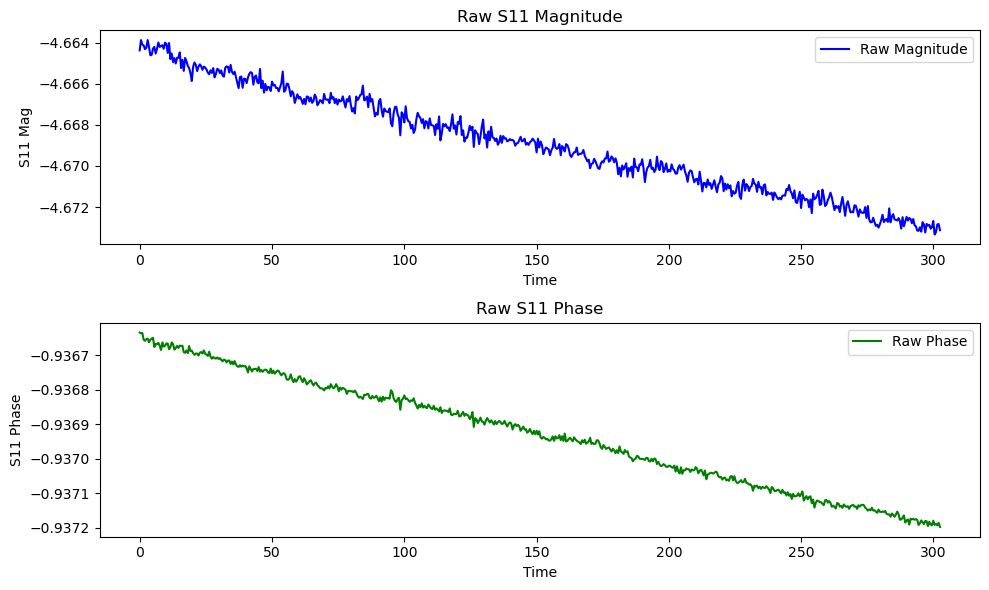

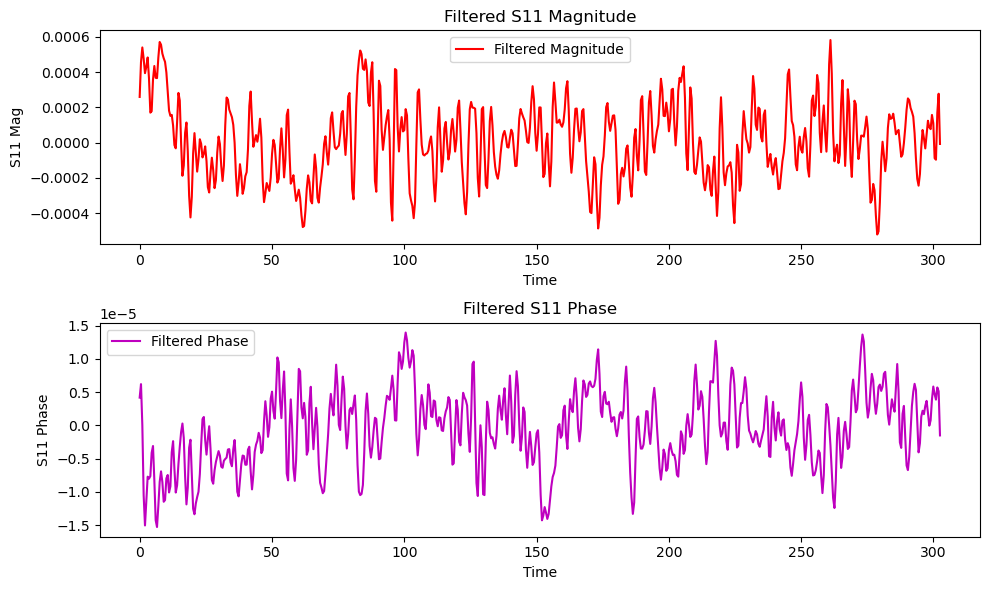

In [ ]:
#---------------------------------------------------
# PLOTTING in separate figures
#---------------------------------------------------

# Figure 1: RAW data only
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(time, s11_mag_raw, 'b-', label='Raw Magnitude')
plt.xlabel('Time')
plt.ylabel('S11 Mag')
plt.title('Raw S11 Magnitude')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, s11_phase_raw, 'g-', label='Raw Phase')
plt.xlabel('Time')
plt.ylabel('S11 Phase')
plt.title('Raw S11 Phase')
plt.legend()

plt.tight_layout()
plt.show()

# Figure 2: FILTERED data only
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(time, s11_mag_filtered, 'r-', label='Filtered Magnitude')
plt.xlabel('Time')
plt.ylabel('S11 Mag')
plt.title('Filtered S11 Magnitude')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, s11_phase_filtered, 'm-', label='Filtered Phase')
plt.xlabel('Time')
plt.ylabel('S11 Phase')
plt.title('Filtered S11 Phase')
plt.legend()

plt.tight_layout()
plt.show()